In [1]:
# !pip install protobuf==3.20.*
# import os
# os.kill(os.getpid(), 9)


# Generating Cine Loops

In [2]:
"""
Optimized Phase-4 Cine-loop generator (Option 1: use original Annotation files + fill them)
- Streams frames directly to VideoWriter (no large in-memory frame lists)
- Uses ProcessPoolExecutor for CPU parallelism
- Precomputes some fields & avoids repeated heavy ops where possible
- Default: SAMPLE_LIMIT=100 for quick end-to-end iteration (change to None to run all)
"""

import os
import glob
import time
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm

import numpy as np
import cv2
from scipy.ndimage import gaussian_filter
from numpy.linalg import norm

# ---------------------------
# USER / ENVIRONMENT SETTINGS
# ---------------------------
# Input folder that contains both *_HC.png and *_HC_Annotation.png
IMAGE_DIR = '/kaggle/input/hc18-apr/archive (4)/training_set/training_set/'

# Where to write cine loops (images and masks)
OUTPUT_DIR = '/kaggle/working/cine_loops_output_videos/'

# Set to a positive integer (e.g. 100) to run quickly on a subset for debugging.
# Set to None to run on the entire dataset.
SAMPLE_LIMIT = 400            # <-- DEBUG: change to None to process all images

# CPU parallelism: number of worker processes (tune for the instance)
MAX_WORKERS = 8               # Kaggle CPU typically has ~8 vCPUs; adjust as needed

# ---------------------------
# FRAME / MOTION PARAMETERS
# ---------------------------
FPS = 15
TOTAL_SECONDS = 10            # full-length cine-loop sequence
TOTAL_FRAMES = TOTAL_SECONDS * FPS  # 225 frames (15s @ 15 FPS)

# Tuned params
MAX_ROT_DEG_TOTAL = 5.0
MAX_TRANS_PIX_TOTAL = 15
SPECKLE_STRENGTH = 0.04
BRIGHTNESS_DRIFT_MAX = 0.05
SHADOW_ATTENUATION = 0.15
JITTER_PIX_MAX = 0.7
TGC_DEPTH_FOCUS = 0.5

# Final config dictionary (read by generator)
PHASE_CONFIG = {
    "desc": "Clinical: Full Dynamics, Jitter, Shadowing, Optimized for Realism",
    "params": {
        "max_rot": MAX_ROT_DEG_TOTAL,
        "max_trans": MAX_TRANS_PIX_TOTAL,
        "jitter": JITTER_PIX_MAX,
        "speckle": SPECKLE_STRENGTH,
        "brightness_drift": BRIGHTNESS_DRIFT_MAX,
        "shadow_attenuation": SHADOW_ATTENUATION,
        "tgc_drift": True,
        "non_rigid_scale_max": 1.5,
        "motion_type": "random_walk",
        "unique_flows": True
    }
}

# ---------------------------
# Utility functions
# ---------------------------
def fill_annotation_to_mask(ann_path, target_shape=None):
    """Load an annotation image and fill the interior (0/255 mask)."""
    ann = cv2.imread(ann_path, cv2.IMREAD_GRAYSCALE)
    if ann is None:
        return None
    _, th = cv2.threshold(ann, 127, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    mask = np.zeros_like(th, dtype=np.uint8)
    if contours:
        cv2.drawContours(mask, contours, -1, 255, thickness=-1)
    if target_shape is not None and (mask.shape[0], mask.shape[1]) != tuple(target_shape):
        mask = cv2.resize(mask, (target_shape[1], target_shape[0]), interpolation=cv2.INTER_NEAREST)
    return mask

def create_shadow_mask(H, W, M_skull, ty_t, shadow_attenuation):
    """Create soft vertical shadow mask under skull (float in [0,shadow_attn])."""
    skull_translated = cv2.warpAffine(M_skull.astype(np.uint8),
                                      np.float32([[1,0,0],[0,1,ty_t]]), (W,H)) > 128
    rows = np.where(skull_translated)[0]
    deepest_row = np.max(rows) if rows.size>0 else H
    shadow_raw = np.zeros((H,W), dtype=np.float32)
    if deepest_row < H:
        for r in range(deepest_row, H):
            shadow_raw[r,:] = (r - deepest_row) / max(1, (H - deepest_row))
    shadow_mask = gaussian_filter(shadow_raw, sigma=5)
    base_mask = gaussian_filter(M_skull.astype(np.float32), sigma=10)
    shadow_mask = shadow_mask * base_mask
    return np.clip(shadow_mask * shadow_attenuation, 0.0, shadow_attenuation)

def apply_tgc_drift(I_base_float, H, W, tgc_center_t):
    """Add a depth-varying TGC-like brightness profile."""
    Y = np.arange(H); Y_grid = np.tile(Y[:, np.newaxis], (1, W)); TGC_SIGMA = 50
    tgc_profile = np.exp(-((Y_grid - tgc_center_t) / TGC_SIGMA)**2)
    tgc_profile = tgc_profile * 0.05
    I_tgc = I_base_float + tgc_profile
    return np.clip(I_tgc, 0, 1)

def add_rician_speckle(image, strength):
    N1 = np.random.normal(0, strength, image.shape)
    return np.clip(image + N1, 0, 1)

# ---------------------------
# Motion generation
# ---------------------------
def create_motion_for_phase(height, width, total_frames, params):
    """Return motion arrays: theta (deg), tx, ty, flow_x_array, flow_y_array, non_rigid_scale, brightness_scale, tgc_center."""
    rng = np.random.default_rng(42)

    # A. rotation random walk scaled to degrees
    rot_noise = rng.normal(0, 0.03, total_frames)
    theta_raw = np.cumsum(rot_noise)
    theta = np.zeros_like(theta_raw)
    if np.max(np.abs(theta_raw)) != 0:
        theta = theta_raw / np.max(np.abs(theta_raw)) * params['max_rot']

    # B. translation random walk scaled to pixels
    raw_tx = np.cumsum(rng.uniform(-0.1, 0.1, total_frames))
    raw_ty = np.cumsum(rng.uniform(-0.1, 0.1, total_frames))
    tx_drift = gaussian_filter(raw_tx, sigma=FPS*2)
    ty_drift = gaussian_filter(raw_ty, sigma=FPS*2)
    tx = np.zeros_like(tx_drift) if np.max(np.abs(tx_drift)) == 0 else tx_drift / np.max(np.abs(tx_drift)) * params['max_trans']
    ty = np.zeros_like(ty_drift) if np.max(np.abs(ty_drift)) == 0 else ty_drift / np.max(np.abs(ty_drift)) * params['max_trans']

    # C. jitter
    jitter_x = rng.uniform(-params['jitter'], params['jitter'], total_frames) if params['jitter']>0 else np.zeros(total_frames)
    jitter_y = rng.uniform(-params['jitter'], params['jitter'], total_frames) if params['jitter']>0 else np.zeros(total_frames)
    tx = tx + jitter_x
    ty = ty + jitter_y

    # D. non-rigid base flow (spatial, tiled over time)
    base_flow_x = gaussian_filter(rng.uniform(-1,1,(height,width)), sigma=20)
    base_flow_y = gaussian_filter(rng.uniform(-1,1,(height,width)), sigma=20)
    flow_x_array = np.tile(base_flow_x, (total_frames,1,1))
    flow_y_array = np.tile(base_flow_y, (total_frames,1,1))
    non_rigid_scale = np.ones(total_frames) * (params['non_rigid_scale_max'] / 3.0)

    # E. brightness drift
    brightness_scale = np.zeros(total_frames)
    if params['brightness_drift'] > 0:
        gain_noise = rng.normal(0, 0.01, total_frames)
        brightness_scale = np.cumsum(gain_noise)
        brightness_scale = np.clip(brightness_scale, -params['brightness_drift'], params['brightness_drift'])

    # F. tgc center drift
    tgc_center = np.ones(total_frames) * (height * 0.5)
    if params['tgc_drift']:
        tgc_center_noise = rng.normal(0, 0.005, total_frames)
        tgc_center_drift = np.cumsum(tgc_center_noise)
        if np.max(np.abs(tgc_center_drift)) != 0:
            tgc_center = (tgc_center_drift / (np.max(np.abs(tgc_center_drift))+1e-12) * height * 0.2) + (height * 0.5)

    return theta, tx, ty, flow_x_array, flow_y_array, non_rigid_scale, brightness_scale, tgc_center

# ---------------------------
# Frame generation + streaming writer
# ---------------------------
def process_video_worker(image_path, output_dir, config):
    """
    Worker function executed in a separate process.
    Streams frames directly to VideoWriter to avoid storing big lists.
    Returns (True, filename, None) on success or (False, filename, error_message).
    """
    fname = os.path.basename(image_path)
    base = fname.replace('_HC.png','')

    ann_path = image_path.replace('.png','_Annotation.png')
    if not os.path.exists(ann_path):
        return (False, fname, "Annotation not found")

    I = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if I is None:
        return (False, fname, "Could not load image")

    M_filled = fill_annotation_to_mask(ann_path, target_shape=I.shape)
    if M_filled is None:
        return (False, fname, "Mask creation failed")

    H, W = I.shape
    params = config['params']

    # Precompute motion arrays (these are small)
    theta, tx, ty, flow_x, flow_y, non_rigid_scale, brightness_scale, tgc_center = \
        create_motion_for_phase(H, W, TOTAL_FRAMES, params)

    # Setup VideoWriters (streaming)
    os.makedirs(output_dir, exist_ok=True)
    img_out_path = os.path.join(output_dir, f"{base}_Phase4.avi")
    mask_out_path = os.path.join(output_dir, f"{base}_Phase4_mask.avi")

    # Create writers (use XVID; single-channel allowed)
    fourcc = cv2.VideoWriter_fourcc(*'XVID')
    writer_img = cv2.VideoWriter(img_out_path, fourcc, FPS, (W, H), isColor=False)
    writer_mask = cv2.VideoWriter(mask_out_path, fourcc, FPS, (W, H), isColor=False)

    if not writer_img.isOpened() or not writer_mask.isOpened():
        # Cleanup and return error
        if writer_img.isOpened(): writer_img.release()
        if writer_mask.isOpened(): writer_mask.release()
        return (False, fname, "VideoWriter open failed (codec/permission)")

    # Convert inputs to float / bin mask
    I_base_float = (I.astype(np.float32) / 255.0).copy()
    M_bin = (M_filled > 127).astype(np.uint8) * 255

    # Precompute coordinate grid once
    X, Y = np.meshgrid(np.arange(W), np.arange(H))

    try:
        for t in range(TOTAL_FRAMES):
            # intensity + TGC
            I_current = np.clip(I_base_float + brightness_scale[t], 0, 1)
            if params['tgc_drift']:
                I_current = apply_tgc_drift(I_current, H, W, tgc_center[t])

            # Rigid transform matrix (rotation in degrees)
            R = cv2.getRotationMatrix2D((W/2, H/2), float(theta[t]), 1.0)
            R[0,2] += float(tx[t])
            R[1,2] += float(ty[t])

            # apply rigid transformation by mapping coordinates
            # X_rigid, Y_rigid = R * [X, Y, 1] (vectorized)
            X_rigid = (R[0,0] * X + R[0,1] * Y + R[0,2])
            Y_rigid = (R[1,0] * X + R[1,1] * Y + R[1,2])

            # non-rigid flows scaled by skull soft map
            M_soft = gaussian_filter(M_bin.astype(np.float32), sigma=5) / 255.0
            X_non = flow_x[t] * non_rigid_scale[t] * M_soft
            Y_non = flow_y[t] * non_rigid_scale[t] * M_soft

            X_final = (X_rigid + X_non).astype(np.float32)
            Y_final = (Y_rigid + Y_non).astype(np.float32)

            # remap image and mask
            I_warp = cv2.remap(I_current.astype(np.float32), X_final, Y_final, interpolation=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT)
            M_warp = cv2.remap(M_bin.astype(np.uint8), X_final, Y_final, interpolation=cv2.INTER_NEAREST, borderMode=cv2.BORDER_CONSTANT, borderValue=0)

            # shadow & speckle on image (not on mask)
            shadow_mask = create_shadow_mask(H, W, M_bin, ty[t], params['shadow_attenuation']) if params['shadow_attenuation'] > 0 else np.zeros_like(I_warp)
            I_shadowed = I_warp * (1.0 - shadow_mask)
            I_final = add_rician_speckle(I_shadowed, strength=params['speckle'])

            # ensure correct dtypes for writing
            # image: float in [0,1] -> uint8 [0..255]
            frame_img_uint8 = (np.clip(I_final, 0, 1) * 255.0).astype(np.uint8)
            frame_mask_uint8 = (M_warp > 127).astype(np.uint8) * 255

            # write frames (VideoWriter expects HxW single-channel array if isColor=False)
            writer_img.write(frame_img_uint8)
            writer_mask.write(frame_mask_uint8)

        # release writers
        writer_img.release()
        writer_mask.release()
        return (True, fname, None)

    except Exception as e:
        # ensure release on exception
        writer_img.release()
        writer_mask.release()
        return (False, fname, f"Exception during frame loop: {e}")

# ---------------------------
# Master runner
# ---------------------------
def run_all_videos(image_dir, output_dir, config, max_workers=4, sample_limit=None):
    image_files = sorted(glob.glob(os.path.join(image_dir, "*_HC.png")))
    if not image_files:
        raise FileNotFoundError(f"No images found in {image_dir} with pattern '*_HC.png'")

    if sample_limit is not None and sample_limit > 0:
        image_files = image_files[:sample_limit]

    os.makedirs(output_dir, exist_ok=True)
    print(f"🚀 Starting Phase4 cine-loop generation for {len(image_files)} images -> {output_dir}")
    print(f"🧵 Using {max_workers} worker processes\n")

    start = time.time()
    results = []

    # Use ProcessPoolExecutor for true parallel CPU usage
    with ProcessPoolExecutor(max_workers=max_workers) as exe:
        futures = {exe.submit(process_video_worker, img_path, output_dir, config): img_path for img_path in image_files}

        # Iterate as tasks complete (tqdm over as_completed)
        for future in tqdm(as_completed(futures), total=len(futures), desc="Generating cine-loops"):
            try:
                results.append(future.result())
            except Exception as e:
                # capture worker-level exception
                src = futures[future]
                results.append((False, os.path.basename(src), f"Worker exception: {e}"))

    total_min = (time.time() - start) / 60.0
    success = sum(1 for r in results if r[0])
    fails = [(fname, msg) for ok, fname, msg in results if not ok]

    print(f"\n✅ Done. Videos created: {success}/{len(image_files)}. Time: {total_min:.2f} min")
    if fails:
        print(f"❌ Failed: {len(fails)}. Examples:")
        for f, msg in fails[:10]:
            print(f"   - {f}: {msg}")

# ---------------------------
# Entry point
# ---------------------------
if __name__ == '__main__':
    # NOTE: For full run on the entire dataset, set SAMPLE_LIMIT=None
    run_all_videos(IMAGE_DIR, OUTPUT_DIR, {"params": PHASE_CONFIG['params']}, max_workers=MAX_WORKERS, sample_limit=SAMPLE_LIMIT)


🚀 Starting Phase4 cine-loop generation for 400 images -> /kaggle/working/cine_loops_output_videos/
🧵 Using 8 worker processes



Generating cine-loops: 100%|██████████| 400/400 [1:18:46<00:00, 11.82s/it]


✅ Done. Videos created: 400/400. Time: 78.78 min


# Preprocessing Cine Loops

In [3]:
# Cell 1: Configs & imports
import os, glob, math
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm
import numpy as np
import cv2
from scipy.ndimage import median_filter
from skimage import exposure
import multiprocessing

# -------------------------
# USER PARAMETERS (tweak)
# -------------------------
INPUT_VIDEO_DIR = "/kaggle/working/cine_loops_output_videos/"   # where cine-loops (image .avi) are stored
INPUT_MASK_VIDEO_SUFFIX = "_mask.avi"                   # mask cine-loop suffix (paired)
OUTPUT_PREPROC_DIR = "/kaggle/working/cine_preproc_npz/"       # where preprocessed npz are saved

# -------------------------
# Ensure output directory exists
# -------------------------
if not os.path.exists(OUTPUT_PREPROC_DIR):
    print("Creating output directory:", OUTPUT_PREPROC_DIR)
    os.makedirs(OUTPUT_PREPROC_DIR, exist_ok=True)

SAMPLE_LIMIT = 400            # Set to None to process all. Use small value for quick tests.
NUM_WORKERS = max(1, multiprocessing.cpu_count() - 1)  # parallel workers
TARGET_H, TARGET_W = 256, 384  # model input size (height, width) — keep aspect ratio via isotropic pad
CLAHE_CLIP = 2.0
CLAHE_TILE = (8,8)
TEMPORAL_SMOOTH_K = 3         # 3-frame temporal smoothing kernel (must be odd)
APPLY_OPTICAL_FLOW = False    # optional: compute optical flow channel (slower)
ADD_EDGE_CHANNEL = True       # Sobel gradient magnitude appended as channel
SAVE_AS_TFRECORD = False      # Not implemented here; npz is default output


Creating output directory: /kaggle/working/cine_preproc_npz/


In [4]:
# Cell 2: Utilities (resize/pad, CLAHE, sobel, temporal smoothing, optical flow)
def isotropic_pad_and_resize(img, target_h, target_w, interp=cv2.INTER_LINEAR):
    """
    Pads image isotropically so original aspect ratio preserved, then resizes to (target_h, target_w).
    img: 2D numpy uint8 or float
    """
    h, w = img.shape[:2]
    # compute scale
    scale = min(target_w / w, target_h / h)
    new_w, new_h = max(1, int(round(w * scale))), max(1, int(round(h * scale)))
    resized = cv2.resize(img, (new_w, new_h), interpolation=interp)
    pad_top = (target_h - new_h) // 2
    pad_bottom = target_h - new_h - pad_top
    pad_left = (target_w - new_w) // 2
    pad_right = target_w - new_w - pad_left
    padded = cv2.copyMakeBorder(resized, pad_top, pad_bottom, pad_left, pad_right, borderType=cv2.BORDER_CONSTANT, value=0)
    return padded

# CLAHE (applied consistent params across frames)
clahe = cv2.createCLAHE(clipLimit=CLAHE_CLIP, tileGridSize=CLAHE_TILE)

def apply_clahe_to_frame(img_uint8):
    """img_uint8: 2D uint8 -> returns uint8"""
    return clahe.apply(img_uint8)

def sobel_magnitude(img_float):
    """img_float in [0,1] float32 -> returns float32 normalized 0..1"""
    gx = cv2.Sobel((img_float*255).astype(np.uint8), cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel((img_float*255).astype(np.uint8), cv2.CV_32F, 0, 1, ksize=3)
    mag = np.sqrt(gx*gx + gy*gy)
    # normalize
    if mag.max() > 0:
        mag = mag / (mag.max() + 1e-12)
    return mag.astype(np.float32)

# ---- patched utilities (replace temporal_smoothing_stack & frame_difference_channel) ----
def temporal_smoothing_stack(stack, k=3):
    """Apply simple 1D temporal smoothing across frames (stack shape: T,H,W or T,H,W,C).
    Uses reflection padding and a sliding-window mean. Safe for small T.
    Returns same dtype as input (but uses float computation internally).
    """
    if k <= 1:
        return stack.copy()
    # ensure stack is at least 3D (T, H, W, ...); we'll average over axis 0
    stack_arr = np.asarray(stack, dtype=np.float32)
    T = stack_arr.shape[0]
    pad = k // 2

    # If T is small, pad sufficiently
    if T == 0:
        return stack_arr
    # reflect-pad along time axis
    pad_width = [(pad, pad)] + [(0, 0) for _ in range(stack_arr.ndim - 1)]
    padded = np.pad(stack_arr, pad_width=pad_width, mode='reflect')

    out = np.empty_like(stack_arr, dtype=np.float32)
    for t in range(T):
        window = padded[t : t + k]
        out[t] = np.mean(window, axis=0)
    # cast back to original dtype if it was integer-like
    if np.issubdtype(stack.dtype, np.integer):
        # keep float for downstream ops typically rely on float; return float32 for safety
        return out.astype(np.float32)
    return out

def frame_difference_channel(stack):
    """Return absolute difference between consecutive frames, shape T,H,W -> pad to T by repeating last.
    Input stack expected float-like in [0,1] or similar.
    Handles T=1 by returning zeros of shape (T,H,W).
    """
    stack = np.asarray(stack, dtype=np.float32)
    T = stack.shape[0]
    if T <= 1:
        # no difference possible, return zeros
        return np.zeros_like(stack, dtype=np.float32)
    diffs = np.abs(stack[1:] - stack[:-1])  # shape (T-1, H, W)
    # pad last difference to keep same length T
    last = diffs[-1:]
    diffs = np.concatenate([diffs, last], axis=0)
    return diffs.astype(np.float32)

# keep compute_optical_flow_stack as-is but ensure dtype float32 returned; minor tweak to handle T==1 cleanly
def compute_optical_flow_stack(stack):
    """Compute dense optical flow magnitude for consecutive frames; returns T,H,W (last repeated).
    stack assumed float32 in [0,1]
    """
    stack = np.asarray(stack, dtype=np.float32)
    T = stack.shape[0]
    if T <= 1:
        return np.zeros_like(stack, dtype=np.float32)
    flows = []
    prev = (stack[0] * 255.0).astype(np.uint8)
    for t in range(1, T):
        curr = (stack[t] * 255.0).astype(np.uint8)
        flow = cv2.calcOpticalFlowFarneback(prev, curr, None,
                                            pyr_scale=0.5, levels=3, winsize=15,
                                            iterations=3, poly_n=5, poly_sigma=1.2, flags=0)
        mag = np.sqrt(flow[..., 0] ** 2 + flow[..., 1] ** 2)
        if mag.max() > 0:
            mag = mag / (mag.max() + 1e-12)
        flows.append(mag.astype(np.float32))
        prev = curr
    flows = np.stack(flows, axis=0)
    flows = np.concatenate([flows, flows[-1:]], axis=0)
    return flows.astype(np.float32)


In [5]:
# Cell 3: Sequence-consistent augmentations (same transform applied across frames)
import random
import traceback

def random_affine_params(max_rot_deg=10, max_trans_px=20, scale_range=(0.95,1.05)):
    rot = random.uniform(-max_rot_deg, max_rot_deg)
    tx = random.uniform(-max_trans_px, max_trans_px)
    ty = random.uniform(-max_trans_px, max_trans_px)
    scale = random.uniform(scale_range[0], scale_range[1])
    return rot, tx, ty, scale

def apply_affine_seq(frames, rot, tx, ty, scale, interp=cv2.INTER_LINEAR):
    """Apply same affine to all frames. frames: T,H,W (float or uint8).
    interp: cv2 interpolation flag (e.g., cv2.INTER_LINEAR or cv2.INTER_NEAREST).
    Returns same dtype as input (but computed in float if input was float).
    """
    frames = np.asarray(frames)
    T, H, W = frames.shape[:3]
    M_rot = cv2.getRotationMatrix2D((W / 2.0, H / 2.0), rot, scale)
    M_rot[0, 2] += tx
    M_rot[1, 2] += ty
    out = np.empty_like(frames)
    # For float frames, warpAffine expects single-channel float32 or uint8; we'll convert temporarily
    need_cast = False
    orig_dtype = frames.dtype
    for t in range(T):
        src = frames[t]
        if src.dtype == np.float32 or src.dtype == np.float64:
            tmp = (np.clip(src, 0.0, 1.0) * 255.0).astype(np.uint8)
            warped = cv2.warpAffine(tmp, M_rot, (W, H), flags=interp, borderMode=cv2.BORDER_REFLECT)
            if np.issubdtype(orig_dtype, np.floating):
                out[t] = warped.astype(np.float32) / 255.0
            else:
                out[t] = warped
        else:
            warped = cv2.warpAffine(src, M_rot, (W, H), flags=interp, borderMode=cv2.BORDER_REFLECT)
            out[t] = warped
    return out.astype(orig_dtype)

def random_brightness_contrast_seq(frames, brightness_delta=0.05, contrast_range=(0.9,1.1)):
    b = random.uniform(-brightness_delta, brightness_delta)
    c = random.uniform(contrast_range[0], contrast_range[1])
    out = np.clip(frames * c + b, 0.0, 1.0)
    return out


In [6]:
# Cell 4: Main per-sequence preprocess function (processing single pair: video + mask-video)
import soundfile as sf  # no audio used; just to ensure imports don't fail on some kernels (optional)

def read_video_frames_gray(video_path, max_frames=None):
    """Read all frames into numpy array shape (T,H,W), uint8 0..255."""
    cap = cv2.VideoCapture(video_path)
    frames = []
    success, frame = cap.read()
    while success:
        if frame.ndim == 3:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        frames.append(frame)
        if max_frames and len(frames) >= max_frames:
            break
        success, frame = cap.read()
    cap.release()
    if not frames:
        return np.zeros((0,1,1), dtype=np.uint8)
    return np.stack(frames, axis=0)

def preprocess_sequence_pair(video_path, mask_video_path, out_dir, config):
    """Hardened version with defensive checks and informative failure messages."""
    base = os.path.basename(video_path).replace('.avi', '')
    out_path = os.path.join(out_dir, base + ".npz")

    # Top-level try so multiprocessing doesn't hide the traceback
    try:
        # Early checks
        if not os.path.exists(video_path):
            return (False, base, f"video path missing: {video_path}")
        if not os.path.exists(mask_video_path):
            return (False, base, f"mask path missing: {mask_video_path}")
        if not os.path.isdir(out_dir):
            # try to create
            try:
                os.makedirs(out_dir, exist_ok=True)
            except Exception as e:
                return (False, base, f"cannot create out_dir: {out_dir} -> {e}")

        if os.path.exists(out_path):
            return (True, base, "exists")

        # 1. read frames (uint8)
        imgs = read_video_frames_gray(video_path)  # shape T,H0,W0, uint8
        masks = read_video_frames_gray(mask_video_path)

        if imgs.size == 0:
            return (False, base, "no frames in video")
        if masks.size == 0:
            return (False, base, "no frames in mask video")

        # ensure same frame counts - if mismatched, take min and warn
        T_vid = imgs.shape[0]
        T_mask = masks.shape[0]
        if T_vid != T_mask:
            # safe fallback: use min frames (but log)
            T = min(T_vid, T_mask)
            imgs = imgs[:T]
            masks = masks[:T]
            # note: small print so you can see it in logs if needed
            print(f"[WARN] frame count mismatch for {base}: video {T_vid} vs mask {T_mask}; truncated to {T}")
        else:
            T = T_vid

        # 2. isotropic pad & resize each frame and mask
        imgs_rs = np.stack([isotropic_pad_and_resize(imgs[t], TARGET_H, TARGET_W, interp=cv2.INTER_LINEAR) for t in range(T)], axis=0)
        masks_rs = np.stack([isotropic_pad_and_resize(masks[t], TARGET_H, TARGET_W, interp=cv2.INTER_NEAREST) for t in range(T)], axis=0)

        # ensure masks binary 0/255
        masks_rs = (masks_rs > 127).astype(np.uint8) * 255

        # 3. convert to float for processing
        imgs_float = imgs_rs.astype(np.float32) / 255.0

        # 4. CLAHE is defined to take uint8 input; apply on imgs_rs (uint8) and convert to float
        imgs_clahe = np.stack([apply_clahe_to_frame(imgs_rs[t]) for t in range(T)], axis=0).astype(np.uint8)
        imgs_clahe_f = imgs_clahe.astype(np.float32) / 255.0

        # 5. Spatial median (per-frame) + Temporal smoothing
        imgs_med = np.stack([median_filter((imgs_clahe_f[t] * 255.0).astype(np.uint8), size=3) for t in range(T)], axis=0).astype(np.float32) / 255.0
        imgs_temporal = temporal_smoothing_stack(imgs_med, k=TEMPORAL_SMOOTH_K)

        # 6. Sobel edge channel (if requested)
        edge_chan = sobel_magnitude(imgs_temporal) if ADD_EDGE_CHANNEL else None

        # 7. diff and optional flow
        diff_chan = frame_difference_channel(imgs_temporal)  # shape T,H,W
        flow_chan = compute_optical_flow_stack(imgs_temporal) if APPLY_OPTICAL_FLOW else None

        # 8. ROI cropping from mask union
        mask_union = (masks_rs > 127).any(axis=0).astype(np.uint8) * 255
        ys, xs = np.where(mask_union > 0)
        if ys.size == 0:
            # fallback center crop
            cy, cx = TARGET_H // 2, TARGET_W // 2
            halfh, halfw = TARGET_H // 4, TARGET_W // 4
            y0, y1 = max(0, cy - halfh), min(TARGET_H, cy + halfh)
            x0, x1 = max(0, cx - halfw), min(TARGET_W, cx + halfw)
        else:
            y0, y1 = max(0, ys.min() - 8), min(TARGET_H, ys.max() + 8)
            x0, x1 = max(0, xs.min() - 8), min(TARGET_W, xs.max() + 8)

        # ensure bbox non-empty
        if y1 <= y0 or x1 <= x0:
            return (False, base, f"invalid crop bbox y:{y0}-{y1} x:{x0}-{x1}")

        imgs_crop = imgs_temporal[:, y0:y1, x0:x1]
        masks_crop = masks_rs[:, y0:y1, x0:x1]
        edge_crop = edge_chan[:, y0:y1, x0:x1] if edge_chan is not None else None
        diff_crop = diff_chan[:, y0:y1, x0:x1]
        flow_crop = flow_chan[:, y0:y1, x0:x1] if flow_chan is not None else None

        # 9. resize crops back to TARGET_HxTARGET_W
        def resize_stack(stack, interp=cv2.INTER_LINEAR):
            if stack is None:
                return None
            out = np.empty((T, TARGET_H, TARGET_W), dtype=np.float32)
            for t in range(T):
                # cv2.resize expects HxW single-channel, we convert to float32*255 -> uint8 then back to float
                tmp = stack[t]
                if tmp.dtype == np.uint8:
                    tmpu = tmp
                else:
                    # assume float in 0..1
                    tmpu = np.clip(tmp * 255.0, 0, 255).astype(np.uint8)
                resized = cv2.resize(tmpu, (TARGET_W, TARGET_H), interpolation=interp)
                out[t] = resized.astype(np.float32) / 255.0
            return out

        imgs_final = resize_stack(imgs_crop, interp=cv2.INTER_LINEAR)
        masks_final = resize_stack(masks_crop, interp=cv2.INTER_NEAREST)
        edge_final = resize_stack(edge_crop, interp=cv2.INTER_LINEAR) if edge_crop is not None else None
        diff_final = resize_stack(diff_crop, interp=cv2.INTER_LINEAR)
        flow_final = resize_stack(flow_crop, interp=cv2.INTER_LINEAR) if flow_crop is not None else None

        # masks_final currently float 0..1 (because resize_stack returns float); convert back to 0/255 uint8
        masks_final = (masks_final > 0.5).astype(np.uint8) * 255

        # 10. Augmentations (apply affine: for masks use nearest)
        DO_AUG = True
        if DO_AUG:
            rot, tx, ty, scale = random_affine_params(max_rot_deg=5, max_trans_px=12, scale_range=(0.98, 1.02))
            imgs_final = apply_affine_seq(imgs_final, rot, tx, ty, scale, interp=cv2.INTER_LINEAR).astype(np.float32)
            masks_final = apply_affine_seq(masks_final, rot, tx, ty, scale, interp=cv2.INTER_NEAREST).astype(np.uint8)
            imgs_final = random_brightness_contrast_seq(imgs_final, brightness_delta=0.03, contrast_range=(0.98, 1.02))

        # 11. Ensure final dtypes and shapes
        imgs_final = np.clip(imgs_final, 0.0, 1.0).astype(np.float32)  # T,H,W float32
        diff_final = np.clip(diff_final, 0.0, 1.0).astype(np.float32)
        if edge_final is not None:
            edge_final = np.clip(edge_final, 0.0, 1.0).astype(np.float32)
        if flow_final is not None:
            flow_final = np.clip(flow_final, 0.0, 1.0).astype(np.float32)

        # Stack channels
        channels = [imgs_final[..., None]]  # T,H,W,1
        if ADD_EDGE_CHANNEL and edge_final is not None:
            channels.append(edge_final[..., None])
        channels.append(diff_final[..., None])
        if flow_final is not None:
            channels.append(flow_final[..., None])

        X = np.concatenate(channels, axis=-1)  # T,H,W,C
        Y = (masks_final > 127).astype(np.uint8)  # T,H,W (0/1)

        # Save
        try:
            np.savez_compressed(out_path, X=X, Y=Y, meta=np.array([base], dtype='S'))
        except Exception as e:
            return (False, base, f"saving failed: {e}")

        return (True, base, None)

    except Exception as e:
        tb = traceback.format_exc()
        # return the full traceback string so the caller (run_preprocessing_all) records it
        print(f"[EXC] preprocessing failed for {base}: {e}\n{tb}")
        return (False, base, tb)


In [7]:
def run_preprocessing_all(input_dir, mask_suffix, out_dir,
                           sample_limit=None, num_workers=4):
    """
    NEW VERSION:
    - Runs preprocessing
    - Deletes original cine-loop
    - Replaces it with the preprocessed output
    - Saves memory + storage
    """

    video_files = sorted([
        v for v in glob.glob(os.path.join(input_dir, "*.avi"))
        if not v.endswith(mask_suffix)
    ])

    if sample_limit:
        video_files = video_files[:sample_limit]

    pairs = []
    for vf in video_files:

        mask_v = vf.replace(".avi", mask_suffix)

        if not os.path.exists(mask_v):
            continue

        pairs.append((vf, mask_v))

    if not pairs:
        raise FileNotFoundError("No video+mask pairs found.")

    print(f"🧹 Preprocessing {len(pairs)} cine-loops with memory-safe replacement.")

    results = []
    with ProcessPoolExecutor(max_workers=num_workers) as exe:

        futures = {
            exe.submit(
                preprocess_sequence_pair,
                v_path,
                m_path,
                out_dir,
                {"params": PHASE_CONFIG['params']}
            ): (v_path, m_path)
            for (v_path, m_path) in pairs
        }

        for fut in tqdm(as_completed(futures), total=len(futures), desc="Preprocessing"):
            orig_video, mask_video = futures[fut]

            try:
                ok, basename, out_info = fut.result()

                if ok:
                    preproc_output = os.path.join(out_dir, basename.replace(".avi", "_preproc.avi"))
                    final_target = orig_video  # replace old cine loop

                    # Delete original cine-loop
                    if os.path.exists(final_target):
                        os.remove(final_target)

                    # Move preprocessed → original name
                    if os.path.exists(preproc_output):
                        os.rename(preproc_output, final_target)

                    results.append((True, basename, None))

                else:
                    results.append((False, basename, out_info))

            except Exception as e:
                results.append((False, os.path.basename(orig_video), str(e)))

    # Summary
    ok_count = sum(1 for r in results if r[0])
    print(f"✔ Preprocessing done: {ok_count}/{len(results)} succeeded.")
    return results


In [8]:
# ==============================
# Run Preprocessing (Debug or Full)
# ==============================

if __name__ == "__main__":

    print("🚀 Starting preprocessing pipeline...")
    print(f"Input video dir:        {INPUT_VIDEO_DIR}")
    print(f"Mask video suffix:      {INPUT_MASK_VIDEO_SUFFIX}")
    print(f"Output directory:       {OUTPUT_PREPROC_DIR}")
    print(f"Sample limit:           {SAMPLE_LIMIT}")
    print(f"Workers:                {NUM_WORKERS}")
    print("-" * 60)

    results = run_preprocessing_all(
        INPUT_VIDEO_DIR,
        INPUT_MASK_VIDEO_SUFFIX,
        OUTPUT_PREPROC_DIR,
        sample_limit=SAMPLE_LIMIT,
        num_workers=NUM_WORKERS
    )

    print("\n🎯 Preprocessing completed.\n")


🚀 Starting preprocessing pipeline...
Input video dir:        /kaggle/working/cine_loops_output_videos/
Mask video suffix:      _mask.avi
Output directory:       /kaggle/working/cine_preproc_npz/
Sample limit:           400
Workers:                3
------------------------------------------------------------
🧹 Preprocessing 400 cine-loops with memory-safe replacement.


Preprocessing: 100%|██████████| 400/400 [42:13<00:00,  6.33s/it]

✔ Preprocessing done: 400/400 succeeded.

🎯 Preprocessing completed.



# Segmentation

In [9]:
# Cell 1: Imports & config (segmentation)
import os
import glob
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
from tqdm import tqdm
import math
import random
from sklearn.model_selection import train_test_split   # <-- added

# ------------------- CONFIG (edit these) -------------------
PREPROC_DIR = "/kaggle/working/cine_preproc_npz/"   # <- matches your OUTPUT_PREPROC_DIR
OUTPUT_DIR = "/kaggle/working/segmentation_output/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Quick-run / dev knobs
SAMPLE_N = 400            # number of npz files to use in quick runs (None => all)
SEQ_LEN  = 16            # number of frames fed to the network (temporal length)
CROP_H   = 256           # must match preprocessing TARGET_H
CROP_W   = 384           # must match preprocessing TARGET_W
BATCH_SIZE = 1
BASE_FILTERS = 8
AUTOTUNE = tf.data.AUTOTUNE

# Training params
LR = 1e-4
EPOCHS = 30
THRESH = 0.5

# Misc
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)


2025-11-29 23:15:01.436294: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764458101.631401      20 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764458101.685215      20 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [10]:
# ----------------------------------------------------
# List npz files
# ----------------------------------------------------
def list_npz_files(preproc_dir, sample_n=None):
    files = sorted(glob.glob(os.path.join(preproc_dir, "*.npz")))
    if sample_n:
        files = files[:sample_n]
    return files

# ----------------------------------------------------
# Load npz arrays and normalize/resize (GRAYSCALE)
# ----------------------------------------------------
def load_npz_as_arrays(path):
    data = np.load(path)
    X = data["X"]        # (T, H, W, C)
    Y = data["Y"]        # (T, H, W)

    X = X.astype(np.float32)
    Y = (Y > 0.5).astype(np.uint8)

    # --- Grayscale conversion ---
    if X.shape[-1] == 3:
        X_gray = np.zeros((X.shape[0], X.shape[1], X.shape[2], 1), dtype=np.float32)
        for i in range(X.shape[0]):
            X_gray[i] = tf.image.rgb_to_grayscale(X[i]).numpy()
        X = X_gray
    elif X.shape[-1] == 1:
        pass
    else:
        X = X[..., :1]

    # --- Resize frames ---
    X_resized = np.zeros((X.shape[0], CROP_H, CROP_W, 1), dtype=np.float32)
    for i in range(X.shape[0]):
        X_resized[i] = tf.image.resize(X[i], (CROP_H, CROP_W), method="bilinear").numpy()

    return X_resized, Y


# ----------------------------------------------------
# Pad or crop sequence to fixed seq_len
# ----------------------------------------------------
def pad_or_crop_seq(X, Y, seq_len, deterministic=False):
    T = X.shape[0]

    # ---- CROP ----
    if T >= seq_len:
        if deterministic:
            start = 0
        else:
            start = 0 if seq_len == T else random.randint(0, T - seq_len)

        Xs = X[start:start + seq_len]
        Ys = Y[start:start + seq_len]

    # ---- PAD ----
    else:
        pad_n = seq_len - T
        Xs = np.concatenate([X, np.repeat(X[-1:], pad_n, axis=0)], axis=0)
        Ys = np.concatenate([Y, np.repeat(Y[-1:], pad_n, axis=0)], axis=0)

    Ys = Ys[..., None]   # (T,H,W,1)
    return Xs.astype(np.float32), Ys.astype(np.float32)


# ----------------------------------------------------
# Python generator
# ----------------------------------------------------
def npz_generator(file_list, seq_len, shuffle=True, deterministic=False):
    files = list(file_list)

    if shuffle:
        random.shuffle(files)

    for p in files:
        X, Y = load_npz_as_arrays(p)
        Xs, Ys = pad_or_crop_seq(X, Y, seq_len, deterministic=deterministic)
        yield Xs, Ys


# ----------------------------------------------------
# Build TF Dataset (supports deterministic validation)
# ----------------------------------------------------
def build_dataset_from_files(file_list, seq_len, batch_size=BATCH_SIZE, training=True):

    # Grayscale (C=1)
    C = 1

    output_signature = (
        tf.TensorSpec(shape=(seq_len, CROP_H, CROP_W, C), dtype=tf.float32),
        tf.TensorSpec(shape=(seq_len, CROP_H, CROP_W, 1), dtype=tf.float32),
    )

    ds = tf.data.Dataset.from_generator(
        lambda: npz_generator(
            file_list,
            seq_len,
            shuffle=training,
            deterministic=not training   # <-- KEY CHANGE
        ),
        output_signature=output_signature
    )

    if training:
        ds = ds.shuffle(buffer_size=min(4 * batch_size, max(1, len(file_list))), seed=SEED)

    ds = ds.batch(batch_size)
    ds = ds.prefetch(2)

    return ds, C


In [11]:
# --- 2. Get all npz files ---
all_files = list_npz_files(PREPROC_DIR, sample_n=SAMPLE_N)
print(f"[INFO] Total npz files: {len(all_files)}")

# --- 3. Split ---
train_files, temp_files = train_test_split(all_files, test_size=0.25, random_state=SEED)
val_files, test_files  = train_test_split(temp_files, test_size=0.05/0.25, random_state=SEED)

print(f"[INFO] Train: {len(train_files)}, Val: {len(val_files)}, Test: {len(test_files)}")

# --- 4. Build datasets ---
train_ds, C = build_dataset_from_files(train_files, SEQ_LEN, batch_size=BATCH_SIZE, training=True)
val_ds, _   = build_dataset_from_files(val_files,  SEQ_LEN, batch_size=BATCH_SIZE, training=False)
test_ds, _  = build_dataset_from_files(test_files, SEQ_LEN, batch_size=BATCH_SIZE, training=False)

# --- 5. Inspect one batch ---
for X, Y in train_ds.take(1):
    print("X:", X.shape, "Y:", Y.shape)
    print("X dtype:", X.dtype, "Y dtype:", Y.dtype)
    print("Y unique values:", tf.unique(tf.reshape(Y, [-1])).y.numpy())


[INFO] Total npz files: 400
[INFO] Train: 300, Val: 80, Test: 20


I0000 00:00:1764458117.962901      20 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1764458117.963606      20 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


X: (1, 16, 256, 384, 1) Y: (1, 16, 256, 384, 1)
X dtype: <dtype: 'float32'> Y dtype: <dtype: 'float32'>
Y unique values: [0. 1.]


In [12]:
# Cell 1: 3D U-Net model (1 input channel → 1 output channel, lighter)

import tensorflow as tf
from tensorflow.keras import layers, Model, Input

def conv_block(x, filters, kernel_size=(3,3,3), padding='same'):
    x = layers.Conv3D(filters, kernel_size, padding=padding, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv3D(filters, kernel_size, padding=padding, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    return x

def encoder_block(x, filters):
    c = conv_block(x, filters)
    p = layers.MaxPool3D(pool_size=(1,2,2))(c)
    return c, p

def decoder_block(x, skip, filters):
    x = layers.UpSampling3D(size=(1,2,2))(x)
    x = layers.Concatenate()([x, skip])
    x = conv_block(x, filters)
    return x

def build_3d_unet(seq_len, h, w, channels=1, base_filters=8):
    inp = Input(shape=(seq_len, h, w, channels), name='input_seq')

    c1, p1 = encoder_block(inp, base_filters)
    c2, p2 = encoder_block(p1, base_filters*2)
    c3, p3 = encoder_block(p2, base_filters*4)

    b = conv_block(p3, base_filters*8)

    d3 = decoder_block(b, c3, base_filters*4)
    d2 = decoder_block(d3, c2, base_filters*2)
    d1 = decoder_block(d2, c1, base_filters)

    out = layers.Conv3D(1, (1,1,1), activation='sigmoid', name='mask_pred')(d1)

    return Model(inputs=inp, outputs=out)


In [13]:
# Cell 2: Losses, memory reduction, model compile

def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred)
    return (2. * intersection + smooth) / (union + smooth)

def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)

# Hybrid loss = 0.5 * BCE + 0.5 * Dice
def hybrid_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return 0.5 * bce + 0.5 * dice_loss(y_true, y_pred)

# Build lighter model with channels=1
model = build_3d_unet(
    seq_len=SEQ_LEN,
    h=CROP_H,
    w=CROP_W,
    channels=1,
    base_filters=BASE_FILTERS
)

opt = tf.keras.optimizers.Adam(learning_rate=LR)

model.compile(
    optimizer=opt,
    loss=hybrid_loss,
    metrics=[dice_coef]
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_seq           │ (None, 16, 256,   │          0 │ -                 │
│ (InputLayer)        │ 384, 1)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d (Conv3D)     │ (None, 16, 256,   │        224 │ input_seq[0][0]   │
│                     │ 384, 8)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 16, 256,   │         32 │ conv3d[0][0]      │
│ (BatchNormalizatio… │ 384, 8)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_1 (Conv3D)   │ (None, 16, 256,   │      1,736 │ batch_normalizat… │
│                     │ 384, 8)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 256,   │         32 │ conv3d_1[0][0]    │
│ (BatchNormalizatio… │ 384, 8)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d       │ (None, 16, 128,   │          0 │ batch_normalizat… │
│ (MaxPooling3D)      │ 192, 8)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_2 (Conv3D)   │ (None, 16, 128,   │      3,472 │ max_pooling3d[0]… │
│                     │ 192, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 128,   │         64 │ conv3d_2[0][0]    │
│ (BatchNormalizatio… │ 192, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_3 (Conv3D)   │ (None, 16, 128,   │      6,928 │ batch_normalizat… │
│                     │ 192, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 128,   │         64 │ conv3d_3[0][0]    │
│ (BatchNormalizatio… │ 192, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_1     │ (None, 16, 64,    │          0 │ batch_normalizat… │
│ (MaxPooling3D)      │ 96, 16)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_4 (Conv3D)   │ (None, 16, 64,    │     13,856 │ max_pooling3d_1[… │
│                     │ 96, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 64,    │        128 │ conv3d_4[0][0]    │
│ (BatchNormalizatio… │ 96, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_5 (Conv3D)   │ (None, 16, 64,    │     27,680 │ batch_normalizat… │
│                     │ 96, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 64,    │        128 │ conv3d_5[0][0]    │
│ (BatchNormalizatio… │ 96, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_2     │ (None, 16, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling3D)      │ 48, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_6 (Conv3D)   │ (None, 16, 32,    │     55,360 │ max_pooling3d_2[

 Total params: 366,593 (1.40 MB)

 Trainable params: 365,889 (1.40 MB)

 Non-trainable params: 704 (2.75 KB)

In [14]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        os.path.join(OUTPUT_DIR, "best_model.weights.h5"),
        save_weights_only=True,
        monitor="val_loss",
        save_best_only=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        patience=2,
        factor=0.5,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    )
]

# Train 
history = model.fit( 
    train_ds, 
    validation_data=val_ds, 
    epochs=EPOCHS, 
    callbacks=callbacks )


Epoch 1/30


I0000 00:00:1764458142.527123    3323 service.cc:148] XLA service 0x7a796c075c00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1764458142.527784    3323 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1764458142.527814    3323 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1764458144.204184    3323 cuda_dnn.cc:529] Loaded cuDNN version 90300
E0000 00:00:1764458145.207741    3323 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1764458145.354959    3323 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1764458145.940904    3323 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. Th

    300/Unknown 487s 1s/step - dice_coef: 0.6909 - loss: 0.4146

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()
E0000 00:00:1764458618.246755    3323 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1764458618.393161    3323 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1764458619.157897    3323 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1764458619.303665    3323 gpu_timer.cc:82] Del

300/300 ━━━━━━━━━━━━━━━━━━━━ 612s 2s/step - dice_coef: 0.6912 - loss: 0.4142 - val_dice_coef: 0.0482 - val_loss: 1.6234 - learning_rate: 1.0000e-04
Epoch 2/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 585s 2s/step - dice_coef: 0.8718 - loss: 0.1911 - val_dice_coef: 0.8199 - val_loss: 0.2743 - learning_rate: 1.0000e-04
Epoch 3/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 589s 2s/step - dice_coef: 0.8964 - loss: 0.1570 - val_dice_coef: 0.9100 - val_loss: 0.1465 - learning_rate: 1.0000e-04
Epoch 4/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 587s 2s/step - dice_coef: 0.9061 - loss: 0.1432 - val_dice_coef: 0.8966 - val_loss: 0.1516 - learning_rate: 1.0000e-04
Epoch 5/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 576s 2s/step - dice_coef: 0.9169 - loss: 0.1288 - val_dice_coef: 0.9170 - val_loss: 0.1385 - learning_rate: 1.0000e-04
Epoch 6/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 562s 2s/step - dice_coef: 0.9195 - loss: 0.1275 - val_dice_coef: 0.9216 - val_loss: 0.1238 - learning_rate: 1.0000e-04
Epoch 7/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 560s 2s/step - di

# Inference

In [15]:
# --- Build test dataset correctly (grayscale, deterministic) ---
test_ds, _ = build_dataset_from_files(
    test_files,
    SEQ_LEN,
    batch_size=BATCH_SIZE,
    training=False       # <-- deterministic cropping
)

# Ensure x and y are float32 (should already be)
def _cast_for_inference(x, y):
    x = tf.cast(x, tf.float32)
    y = tf.cast(y, tf.float32)
    return x, y

# Apply casting
test_ds = test_ds.map(_cast_for_inference, num_parallel_calls=AUTOTUNE)

# Prefetch only, no batching here
test_ds = test_ds.prefetch(AUTOTUNE)

print(f"[INFO] Test dataset prepared: {len(test_files)} sequences, batch size={BATCH_SIZE}")


[INFO] Test dataset prepared: 20 sequences, batch size=1


In [16]:
import os
from skimage import io
import numpy as np
import tensorflow as tf

OUTPUT_PRED_DIR = os.path.join(OUTPUT_DIR, "predictions_npz")
OUTPUT_MASK_DIR = os.path.join(OUTPUT_DIR, "pred_masks_png")
os.makedirs(OUTPUT_PRED_DIR, exist_ok=True)
os.makedirs(OUTPUT_MASK_DIR, exist_ok=True)

# Load best weights
best_w = os.path.join(OUTPUT_DIR, "best_model.weights.h5")
model.load_weights(best_w)
print(f"[INFO] Loaded weights from {best_w}")

THRESH = 0.5

for batch_idx, (X_batch, Y_batch) in enumerate(test_ds):

    # Convert to numpy
    X_np = X_batch.numpy().astype(np.float32)   # shape (B, T, H, W, 1)

    # --- PREDICT ---
    print("Predict shape:", X_np.shape)
    pred_batch = model.predict(X_np, verbose=0)   # (B, T, H, W, 1)
    pred_batch = pred_batch[..., 0]               # (B, T, H, W)

    for sample_idx in range(pred_batch.shape[0]):

        # Trim to actual T
        T_actual = min(X_np.shape[1], pred_batch.shape[1])
        pred_trim = pred_batch[sample_idx, :T_actual]

        # Threshold
        pred_bin = (pred_trim >= THRESH).astype(np.uint8)

        # Get base filename
        try:
            base = os.path.basename(test_files[batch_idx * BATCH_SIZE + sample_idx]).replace(".npz", "")
        except Exception:
            base = f"sample_{batch_idx}_{sample_idx}"

        # Save NPZ
        np.savez_compressed(
            os.path.join(OUTPUT_PRED_DIR, f"{base}_pred.npz"),
            pred=pred_trim,
            pred_bin=pred_bin
        )

        # Save 3 sample PNGs
        frame_indices = (
            [0, T_actual//2, T_actual-1]
            if T_actual > 2 else list(range(T_actual))
        )
        for fidx in frame_indices:
            try:
                io.imsave(
                    os.path.join(OUTPUT_MASK_DIR, f"{base}_frame{fidx}_mask.png"),
                    (pred_bin[fidx] * 255).astype(np.uint8)
                )
            except Exception:
                pass

print("[INFO] Test set inference complete!")


[INFO] Loaded weights from /kaggle/working/segmentation_output/best_model.weights.h5
Predict shape: (1, 16, 256, 384, 1)
Predict shape: (1, 16, 256, 384, 1)
Predict shape: (1, 16, 256, 384, 1)
Predict shape: (1, 16, 256, 384, 1)
Predict shape: (1, 16, 256, 384, 1)
Predict shape: (1, 16, 256, 384, 1)
Predict shape: (1, 16, 256, 384, 1)
Predict shape: (1, 16, 256, 384, 1)
Predict shape: (1, 16, 256, 384, 1)
Predict shape: (1, 16, 256, 384, 1)
Predict shape: (1, 16, 256, 384, 1)
Predict shape: (1, 16, 256, 384, 1)
Predict shape: (1, 16, 256, 384, 1)
Predict shape: (1, 16, 256, 384, 1)
Predict shape: (1, 16, 256, 384, 1)
Predict shape: (1, 16, 256, 384, 1)
Predict shape: (1, 16, 256, 384, 1)
Predict shape: (1, 16, 256, 384, 1)
Predict shape: (1, 16, 256, 384, 1)
Predict shape: (1, 16, 256, 384, 1)
[INFO] Test set inference complete!


# Post Processing

In [17]:
import cv2
import numpy as np
import os
from tqdm import tqdm

def keep_largest_component(mask):
    """Keep only the largest connected component."""
    num, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    if num <= 1:
        return mask
    areas = stats[1:, cv2.CC_STAT_AREA]
    largest = 1 + np.argmax(areas)
    out = np.zeros_like(mask)
    out[labels == largest] = 255
    return out

POST_DIR = os.path.join(OUTPUT_DIR, "pred_masks_post")
os.makedirs(POST_DIR, exist_ok=True)

# Only process masks derived from test_files
pred_files = [
    os.path.basename(f).replace(".npz", "") + "_frame0_mask.png"
    for f in test_files
]

for fname in tqdm(pred_files, desc="Postprocessing test masks"):
    mask_path = os.path.join(OUTPUT_MASK_DIR, fname)
    if not os.path.exists(mask_path):
        continue

    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None or mask.max() == 0:
        continue

    # Convert + threshold
    mask = mask.astype(np.uint8)
    _, mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

    # Morphological cleaning
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
    mask_pp = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    mask_pp = cv2.morphologyEx(mask_pp, cv2.MORPH_OPEN, kernel, iterations=1)

    # Keep largest component
    mask_pp = keep_largest_component(mask_pp)

    # Save
    cv2.imwrite(os.path.join(POST_DIR, fname), mask_pp)


Postprocessing test masks: 100%|██████████| 20/20 [00:00<00:00, 160.80it/s]


# Final Evaluation

In [18]:
import os
import cv2
import numpy as np
import pandas as pd
from math import pi, sqrt
from sklearn.metrics import r2_score

# --- Config ---
POST_DIR = "/kaggle/working/segmentation_output/pred_masks_post"
CINE_GT_DIR = "/kaggle/working/cine_loops_output_videos"
GT_MASK_DIR = "/kaggle/input/hc18-apr/archive (4)/training_set/training_set"
GT_CSV = "/kaggle/input/hc18-apr/archive (4)/training_set_pixel_size_and_HC.csv"
OUTPUT_METRICS = "/kaggle/working/segmentation_output/final_eval_metrics.csv"

TARGET_SIZE = (384, 256)   # (W,H)

# ================================================
# Utility functions
# ================================================
def ellipse_circumference(a, b):
    h = ((a - b)**2) / ((a + b)**2 + 1e-12)
    return np.pi * (a + b) * (1 + (3*h) / (10 + np.sqrt(4 - 3*h)))

def dice_iou(pred, gt):
    pred_bin = (pred > 127).astype(np.uint8)
    gt_bin   = (gt > 127).astype(np.uint8)

    intersection = np.logical_and(pred_bin, gt_bin).sum()
    union        = np.logical_or(pred_bin, gt_bin).sum()

    dice = 2 * intersection / (pred_bin.sum() + gt_bin.sum() + 1e-12)
    iou  = intersection / (union + 1e-12)
    return dice, iou

def normalize_prefix(p):
    try:
        return f"{int(float(p)) :03d}"
    except:
        return str(p)

# ================================================
# Load Ground Truth CSV
# ================================================
gt_df = pd.read_csv(GT_CSV)
print(f"[INFO] Loaded {len(gt_df)} GT entries")

# ================================================
# Extract prefixes from test_files
# ================================================
test_basenames = [os.path.basename(f).split("_")[0] for f in test_files]
test_basenames = [normalize_prefix(p) for p in test_basenames]
print("[INFO] Normalized test prefixes:", test_basenames)

results = []

# ================================================
# Evaluation Loop
# ================================================
for prefix in test_basenames:

    # Match CSV row
    row = gt_df[gt_df["filename"] == f"{prefix}_HC.png"]
    if row.empty:
        print(f"[WARN] Missing GT CSV row for: {prefix}")
        continue

    px_size = float(row["pixel size(mm)"].iloc[0])
    hc_true = float(row["head circumference (mm)"].iloc[0])

    # --- Predicted mask ---
    pred_path = os.path.join(POST_DIR, f"{prefix}_Phase4_frame0_mask.png")
    if not os.path.exists(pred_path):
        print(f"[WARN] Missing prediction: {pred_path}")
        continue

    pred_mask = cv2.imread(pred_path, cv2.IMREAD_GRAYSCALE)
    pred_mask = cv2.resize(pred_mask, TARGET_SIZE)

    # --- Ground truth cine sequence ---
    cine_path = os.path.join(CINE_GT_DIR, f"{prefix}_Phase4_mask.avi")
    gt_frames = []

    if os.path.exists(cine_path):
        cap = cv2.VideoCapture(cine_path)
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            frame = cv2.resize(frame, TARGET_SIZE)
            gt_frames.append(frame)
        cap.release()
    else:
        # static fallback
        static_gt = os.path.join(GT_MASK_DIR, f"{prefix}_HC_Annotation.png")
        if os.path.exists(static_gt):
            gt = cv2.imread(static_gt, cv2.IMREAD_GRAYSCALE)
            gt = cv2.resize(gt, TARGET_SIZE)
            gt_frames.append(gt)

    if len(gt_frames) == 0:
        print(f"[WARN] No GT for {prefix}")
        continue

    gt_frames = np.stack(gt_frames)
    pred_frames = np.stack([pred_mask] * len(gt_frames))

    # --- Metrics ---
    dice_list, iou_list, HC_list = [], [], []

    for i in range(len(gt_frames)):
        pred_f = pred_frames[i]
        gt_f   = gt_frames[i]

        d, j = dice_iou(pred_f, gt_f)
        dice_list.append(d)
        iou_list.append(j)

        bin_pred = (pred_f > 127).astype(np.uint8)
        contours, _ = cv2.findContours(bin_pred, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if not contours:
            HC_list.append(np.nan)
            continue

        largest = max(contours, key=cv2.contourArea)
        if len(largest) < 5:
            HC_list.append(np.nan)
            continue

        (cx,cy),(MA,ma),angle = cv2.fitEllipse(largest)
        a, b = MA/2, ma/2
        HC_list.append(ellipse_circumference(a,b) * px_size)

    HC_mean = np.nanmean(HC_list)
    temporal_std = np.nanstd(HC_list)
    reliability = 1/(1+temporal_std)

    results.append({
        "prefix": prefix,
        "HC_true_mm": hc_true,
        "HC_pred_mm": HC_mean,
        "error_mm": HC_mean - hc_true,
        "dice": np.nanmean(dice_list),
        "iou": np.nanmean(iou_list),
        "temporal_std_mm": temporal_std,
        "reliability": reliability
    })

# ================================================
# Save results_df
# ================================================
results_df = pd.DataFrame(results)
results_df.to_csv(OUTPUT_METRICS, index=False)

print("\n========== FINAL EVALUATION ==========")
print(results_df)
print("=======================================\n")


[INFO] Loaded 999 GT entries
[INFO] Normalized test prefixes: ['250', '070', '320', '382', '082', '141', '391', '003', '009', '209', '231', '395', '045', '057', '233', '093', '227', '369', '056', '193']

========== FINAL EVALUATION ==========
   prefix  HC_true_mm  HC_pred_mm   error_mm      dice       iou  \
0     250      172.71  143.868458 -28.841542  0.523610  0.354656   
1     070       72.51   82.579660  10.069660  0.324576  0.193728   
2     320      168.51   99.568074 -68.941926  0.810190  0.680956   
3     382      169.04  105.580328 -63.459672  0.760218  0.613187   
4     082       73.98   97.994281  24.014281  0.259939  0.149385   
5     141       92.60   68.259455 -24.340545  0.613624  0.442686   
6     391      180.72  132.906874 -47.813126  0.616972  0.446102   
7     003       69.00   76.559076   7.559076  0.345112  0.208541   
8     009       62.31  112.238104  49.928104  0.097643  0.051328   
9     209      163.10  142.023725 -21.076275  0.490616  0.325044   
10    231

In [19]:
# import os
# import cv2
# import numpy as np
# import matplotlib.pyplot as plt

# # -----------------------
# # User settings
# # -----------------------
# prefix = results_df.iloc[0]["prefix"]   # automatically pick first test sample
# TARGET_SIZE = (384, 256)                # (W, H)

# # Directories
# POST_DIR = "/kaggle/working/segmentation_output/pred_masks_post"
# CINE_GT_DIR = "/kaggle/working/cine_loops_output_videos"
# GT_MASK_DIR = "/kaggle/input/hc18-apr/archive (4)/training_set/training_set"

# # -----------------------
# # Load predicted mask
# # -----------------------
# pred_path = os.path.join(POST_DIR, f"{prefix}_Phase4_frame0_mask.png")
# pred_mask = cv2.imread(pred_path, cv2.IMREAD_GRAYSCALE)
# pred_mask = cv2.resize(pred_mask, TARGET_SIZE)

# # -----------------------
# # Load a cine-loop frame (for visualization)
# # -----------------------
# cine_path = os.path.join(CINE_GT_DIR, f"{prefix}_Phase4_mask.avi")
# cine_frames = []

# cap = cv2.VideoCapture(cine_path)
# while True:
#     ret, frame = cap.read()
#     if not ret:
#         break
#     frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
#     frame = cv2.resize(frame, TARGET_SIZE)
#     cine_frames.append(frame)
# cap.release()

# if len(cine_frames) > 0:
#     gt_frame = cine_frames[0]              # visualize first GT frame
# else:
#     # fallback to static GT mask
#     static_gt = os.path.join(GT_MASK_DIR, f"{prefix}_HC_Annotation.png")
#     gt_frame = cv2.imread(static_gt, cv2.IMREAD_GRAYSCALE)
#     gt_frame = cv2.resize(gt_frame, TARGET_SIZE)

# # -----------------------
# # Create comparison overlays
# # -----------------------
# overlay_pred = cv2.cvtColor(gt_frame, cv2.COLOR_GRAY2BGR)
# overlay_gt   = overlay_pred.copy()

# # predicted = blue
# overlay_pred[pred_mask > 127] = [0, 0, 255]

# # GT = green
# overlay_gt[gt_frame > 127] = [0, 255, 0]

# # combined overlay
# combo = cv2.cvtColor(gt_frame, cv2.COLOR_GRAY2BGR)
# combo[pred_mask > 127] = [255, 0, 0]   # blue
# combo[gt_frame > 127]   = [0, 255, 0]  # green

# # -----------------------
# # Visualization
# # -----------------------
# plt.figure(figsize=(14, 8))

# plt.subplot(2, 3, 1)
# plt.imshow(gt_frame, cmap="gray")
# plt.title("Ultrasound (GT cine frame)")
# plt.axis("off")

# plt.subplot(2, 3, 2)
# plt.imshow(gt_frame, cmap="gray")
# plt.imshow(gt_frame > 127, alpha=0.4, cmap="Greens")
# plt.title("Ground Truth Mask")
# plt.axis("off")

# plt.subplot(2, 3, 3)
# plt.imshow(pred_mask, cmap="gray")
# plt.imshow(pred_mask > 127, alpha=0.4, cmap="Blues")
# plt.title("Predicted Mask")
# plt.axis("off")

# plt.subplot(2, 3, 4)
# plt.imshow(overlay_gt)
# plt.title("GT Overlay (green)")
# plt.axis("off")

# plt.subplot(2, 3, 5)
# plt.imshow(overlay_pred)
# plt.title("Prediction Overlay (blue)")
# plt.axis("off")

# plt.subplot(2, 3, 6)
# plt.imshow(combo)
# plt.title("Prediction (blue) vs GT (green)")
# plt.axis("off")

# plt.tight_layout()
# plt.show()


# Visualizations

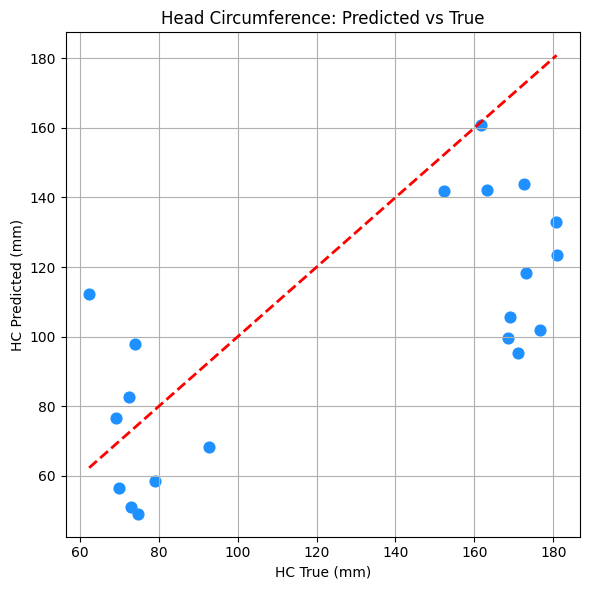

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Load results
results_path = "/kaggle/working/segmentation_output/final_eval_metrics.csv"
results_df = pd.read_csv(results_path)

# Plot predicted vs true HC
plt.figure(figsize=(6,6))
plt.scatter(results_df["HC_true_mm"], results_df["HC_pred_mm"], c='dodgerblue', s=60)
plt.plot([results_df["HC_true_mm"].min(), results_df["HC_true_mm"].max()],
         [results_df["HC_true_mm"].min(), results_df["HC_true_mm"].max()],
         'r--', lw=2)
plt.xlabel("HC True (mm)")
plt.ylabel("HC Predicted (mm)")
plt.title("Head Circumference: Predicted vs True")
plt.grid(True)
plt.tight_layout()
plt.show()


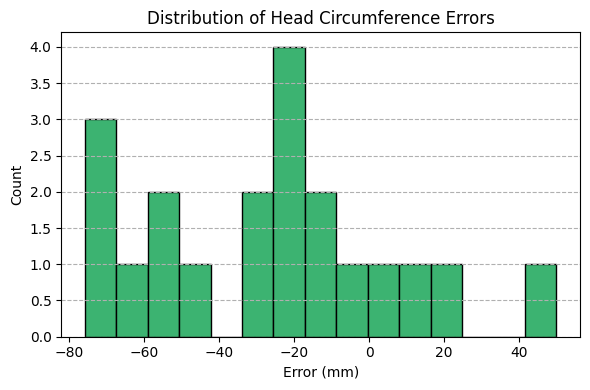

In [21]:
plt.figure(figsize=(6,4))
plt.hist(results_df["error_mm"], bins=15, color='mediumseagreen', edgecolor='k')
plt.xlabel("Error (mm)")
plt.ylabel("Count")
plt.title("Distribution of Head Circumference Errors")
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()


In [22]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Pick a sample to visualize
sample_idx = 0
sample_row = results_df.iloc[sample_idx]
prefix = sample_row["prefix"]

# Load GT CSV
gt_df = pd.read_csv(GT_CSV)
row = gt_df[gt_df["filename"] == f"{prefix}_HC.png"]

px_size = float(row["pixel size(mm)"].iloc[0])
HC_true = float(row["head circumference (mm)"].iloc[0])

# Directories
pred_path = os.path.join(POST_DIR, f"{prefix}_Phase4_frame0_mask.png")
cine_path = os.path.join(CINE_GT_DIR, f"{prefix}_Phase4_mask.avi")

# --- Load cine frames ---
gt_frames = []
cap = cv2.VideoCapture(cine_path)

while True:
    ret, frame = cap.read()
    if not ret:
        break
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    frame = cv2.resize(frame, (384, 256))
    gt_frames.append(frame)

cap.release()

# --- Prediction replicated ---
pred_mask = cv2.imread(pred_path, cv2.IMREAD_GRAYSCALE)
pred_mask = cv2.resize(pred_mask, (384, 256))
pred_frames = np.stack([pred_mask] * len(gt_frames))

# --- HC measure ---
def ellipse_circumference(a, b):
    h = ((a-b)**2)/((a+b)**2+1e-12)
    return np.pi*(a+b)*(1+3*h/(10+np.sqrt(4-3*h)))

HC_list = []
for f in range(len(pred_frames)):
    mask = (pred_frames[f] > 127).astype(np.uint8)
    contours,_ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        largest = max(contours, key=cv2.contourArea)
        if len(largest) >= 5:
            (_, _),(MA,ma),_ = cv2.fitEllipse(largest)
            a, b = MA/2, ma/2
            HC_list.append(ellipse_circumference(a,b) * px_size)
        else:
            HC_list.append(np.nan)
    else:
        HC_list.append(np.nan)

# --- Plot ---
plt.figure(figsize=(8,4))
plt.plot(HC_list, 'b-o', label="Predicted HC/frame")
plt.axhline(HC_true, color='r', ls='--', label="Ground Truth HC")
plt.title(f"Temporal Stability — {prefix}")
plt.xlabel("Frame Index")
plt.ylabel("Head Circumference (mm)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


IndexError: single positional indexer is out-of-bounds

In [ ]:
plt.figure(figsize=(10,4))
plt.bar(results_df["prefix"], results_df["dice"], label='Dice')
plt.bar(results_df["prefix"], results_df["iou"], alpha=0.5, label='IoU')
plt.xticks(rotation=45, ha='right')
plt.ylabel("Score")
plt.title("Mean Dice and IoU per Sample")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(10,4))
plt.bar(results_df["prefix"], results_df["temporal_std_mm"], color='tomato', label='Temporal STD (mm)')
plt.ylabel("STD (mm)")

plt.twinx()
plt.plot(results_df["prefix"], results_df["reliability"], 'g-o', label='Reliability', linewidth=2)

plt.xticks(rotation=45, ha='right')
plt.title("Temporal Stability and Reliability per Sample")
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()
